In [2]:
####
library(dplyr)
library(Matrix)
library(data.table)
library(Seurat)
library(ggplot2)
library(RColorBrewer)
library(ggalluvial)
library(readxl)
library(dplyr)
library(reshape2)
library(ggsci)
library(tidyr)
library(dplyr)
library(ggpubr)
library(reshape2)
library(purrr)
library(ggplot2)
library(dplyr)
library(cowplot)
cluster = c('EX_DG','EX_CA1','EX_CA2',
             'EX_CA3-4.0','EX_CA3-4.1','EX_CA3-4.2','EX_CA3-4.3','EX_CA3-4.4',
             'EX_Sub',
             'Astro.0','Astro.1','Astro.2','Astro.3',
             'Oligo','OPC',
             'Micro.0','Micro.1','Micro.2','Micro.3','Micro.4',
             'IN_SST','IN_VIP','IN_PVALB','IN_LAMP5','Endo','Pericyte','Fibroblast','Ependy','Blood')
cols = c( '#cb5c83','#FE8A23',"#a4cee1",
                '#FFCDD2','#EF9A9A','#E57373','#E53935','#C62828',
                "#ff6699",
                '#22b8cf','#91a7ff','#228be6','#364fc7',
                '#9ECB3D','#158942',
                '#E6EE9C','#D4E157','#e6d933','#C0CA33','#9E9D24',
                '#D4E157','#8D6E63','#9B7BFA','#78E08F','#94AF97','#868e96','#c7c6b6','#D3A59C','#B2847B')
names(cols) = cluster
cluster_levels = c('EX_DG','EX_CA1','EX_CA2','EX_CA3-4.0','EX_CA3-4.1','EX_CA3-4.2','EX_CA3-4.3','EX_CA3-4.4','Astro.0','Astro.1','Astro.2','Astro.3','Oligo','OPC','Micro.0','Micro.1','Micro.2','Micro.3','Micro.4', 'IN_SST','IN_VIP','IN_PVALB','IN_LAMP5','Endo','Pericyte','Fibroblast','Ependy','Blood')



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


Attaching SeuratObject


Attaching package: ‘reshape2’


The following objects are masked from ‘package:data.table’:

    dcast, melt



Attaching package: ‘tidyr’


The following object is masked from ‘package:reshape2’:

    smiths


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack



Attaching package: ‘purrr’


The following object is masked from ‘package:data.table’:

    transpose



Attaching package: ‘cowplot’


The following object is masked from ‘package:ggpubr’:

    get_legend




In [3]:
meta = readRDS("allmetadata-subcluster_0806.rds")
meta$sample = meta$chip_id
meta$state = meta$Group
meta[which(meta$state =="HS"),]$state = "Sclerosis"
meta = meta %>% filter(sample %in% setdiff(unique(meta$sample),c("HS42Y","HS8")))
metadata = meta[,c("ry","rx","subcluster","Group","area_m","sample","state")]
colnames(metadata)=c("coor_y","coor_x","transfer.celltype","group","area","Chip","state")

calculate_distances <- function(df, l2_it_cells) {
  distances <- outer(df$coor_x, l2_it_cells$coor_x, "-")^2 +
               outer(df$coor_y, l2_it_cells$coor_y, "-")^2
  sqrt(distances)
}

#####################################################
subclass.cluster.info= unique(meta[,c("subcluster","CellType")])
colnames(subclass.cluster.info)=c("celltype","subclass")
subclass.cluster.info[1:2,]

,celltype,subclass
,<chr>,<chr>
1,EX_CA1,EX_CA1
2,OPC,OPC


In [ ]:
celltypes <- c('EX_CA3-4.0','EX_CA3-4.1','EX_CA3-4.2','EX_CA3-4.3','EX_CA3-4.4')  
area = c('CA3','CA4')
combined_final_results <- data.frame()


for (celltype in celltypes) {
  cat("\n#########################################################\n")
  cat("start cell type:", celltype, "\n")
  df = metadata[metadata$area %in% area, ]
  

  target_cells <- df %>%
    dplyr::filter(transfer.celltype == celltype) %>%  
    dplyr::select(Chip, coor_x, coor_y)
  

  dis_values <- c(40, 80, 120, 160, 200)

  df_within_range.all <- NULL

  for (dis in dis_values) {
    df_within_range <- df %>%
      group_by(Chip) %>%
      mutate(
        within_range = {
          current_chip <- unique(Chip)
          chip_target_cells <- target_cells %>% 
            dplyr::filter(Chip == current_chip)
          
          if (nrow(chip_target_cells) == 0) {
            rep(FALSE, n())
          } else {
           
            current_cells <- cur_data_all()  #
            
            
            non_self_mask <- current_cells$transfer.celltype != celltype
            distances <- calculate_distances(
              current_cells[non_self_mask, ], 
              chip_target_cells
            )
            
          
            result <- rep(FALSE, nrow(current_cells))
            result[non_self_mask] <- apply(distances, 1, function(row) any(row <= dis))
            result
          }
        }
      ) %>% 
      ungroup()
    

    df_within_range$id <- paste0(df_within_range$coor_y, "_", df_within_range$coor_x)
    

    col_name <- paste0("dis", dis, "um_out")
    names(df_within_range)[names(df_within_range) == "within_range"] <- col_name
    

    if (is.null(df_within_range.all)) {
      df_within_range.all <- df_within_range
    } else {
      new_cols <- df_within_range[, c("id", col_name)]
      df_within_range.all <- merge(
        df_within_range.all, 
        new_cols,
        by = "id",
        all = TRUE
      )
    }
  }
  

  df_within_range.all$state <- with(df_within_range.all, paste(
    dis40um_out, dis80um_out, dis120um_out, dis160um_out, dis200um_out, 
    sep = "_"
  ))
  
  dis20 <- df_within_range.all %>% 
    filter(dis40um_out == TRUE & transfer.celltype != celltype)
  cat(paste0("0-20μm: ", nrow(dis20), "\n"))
  
  dis40 <- df_within_range.all %>% 
    filter(dis80um_out == TRUE & transfer.celltype != celltype)
  cat(paste0("0-40μm: ", nrow(dis40), "\n"))
  
  dis60 <- df_within_range.all %>% 
    filter(dis120um_out == TRUE & transfer.celltype != celltype)
  cat(paste0("0-60μm: ", nrow(dis60), "\n"))
  
  dis80 <- df_within_range.all %>% 
    filter(dis160um_out == TRUE & transfer.celltype != celltype)
  cat(paste0("0-80μm: ", nrow(dis80), "\n"))
  
  dis100 <- df_within_range.all %>% 
    filter(dis200um_out == TRUE & transfer.celltype != celltype)
  cat(paste0("0-100μm: ", nrow(dis100), "\n"))
  

  

  calculate_cell_ratio <- function(data, distance_label, target_type) {
    if (nrow(data) == 0) {
      return(data.frame(
        cell_type = character(),
        Group = character(),
        sample = character(),
        distance_interval = character(),
        target_cell_type = character(),
        analysis_date = character(),
        Freq = numeric()
      ))
    }
    

    filtered_data <- data %>% filter(transfer.celltype != target_type)
    
    if (nrow(filtered_data) == 0) {
      return(data.frame(
        cell_type = character(),
        Group = character(),
        sample = character(),
        distance_interval = character(),
        target_cell_type = character(),
        analysis_date = character(),
        Freq = numeric()
      ))
    }
    

    filtered_data$group_chip <- paste0(filtered_data$group, "_", filtered_data$Chip)
    
    ratio_matrix <- prop.table(
      table(filtered_data$transfer.celltype, filtered_data$group_chip), 
      margin = 2
    )
    

    ratio_df <- as.data.frame(ratio_matrix) %>%
      rename(
        cell_type = Var1,
        group_chip = Var2
      ) %>%
      separate(
        col = group_chip,
        into = c("Group", "sample"),
        sep = "_",
        remove = TRUE
      ) %>%
      mutate(
        distance_interval = distance_label,
        target_cell_type = target_type,
        analysis_date = format(Sys.time(), "%Y-%m-%d %H:%M:%S %Z")
      )
    
    return(ratio_df)
  }
  

  cellratio_20 <- calculate_cell_ratio(dis20, "20", celltype)
  cellratio_20_40 <- calculate_cell_ratio(
    df_within_range.all %>% filter(id %in% setdiff(dis40$id, dis20$id)), 
    "20_40", 
    celltype
  )
  cellratio_40_60 <- calculate_cell_ratio(
    df_within_range.all %>% filter(id %in% setdiff(dis60$id, dis40$id)), 
    "40_60", 
    celltype
  )
  cellratio_60_80 <- calculate_cell_ratio(
    df_within_range.all %>% filter(id %in% setdiff(dis80$id, dis60$id)), 
    "60_80", 
    celltype
  )
  cellratio_80_100 <- calculate_cell_ratio(
    df_within_range.all %>% filter(id %in% setdiff(dis100$id, dis80$id)), 
    "80_100", 
    celltype
  )
  

  final_result <- bind_rows(
    cellratio_20,
    cellratio_20_40,
    cellratio_40_60,
    cellratio_60_80,
    cellratio_80_100
  ) %>%
    mutate(across(where(is.numeric), ~ replace_na(., 0)))
  

  combined_final_results <- bind_rows(combined_final_results, final_result)
  
  cat("\ncelltype:", celltype)
}

write.csv(combined_final_results, "Combined_CellRatio_ExcludedSelf.csv", row.names = FALSE)


In [5]:
# long to  wide
combined_final_results_wide <- combined_final_results %>%
  pivot_wider(
    names_from = distance_interval,
    values_from = Freq,
    values_fill = 0
  )

# cat data
head(combined_final_results_wide)

cell_type,Group,sample,target_cell_type,analysis_date,20,20_40,40_60,60_80,80_100
<fct>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Astro.0,HS,HS26,EX_CA3-4.0,2026-07-08 13:27:48 CST,0.07692308,0.13636364,0.101265823,0.169675090,0.13380282
Astro.1,HS,HS26,EX_CA3-4.0,2026-07-08 13:27:48 CST,0.01098901,0.06060606,0.092827004,0.079422383,0.06690141
Astro.2,HS,HS26,EX_CA3-4.0,2026-07-08 13:27:48 CST,0.04395604,0.06060606,0.084388186,0.101083032,0.11971831
Astro.3,HS,HS26,EX_CA3-4.0,2026-07-08 13:27:48 CST,0.00000000,0.01010101,0.008438819,0.003610108,0.01760563
Blood,HS,HS26,EX_CA3-4.0,2026-07-08 13:27:48 CST,0.02197802,0.01515152,0.012658228,0.014440433,0.01056338
Endo,HS,HS26,EX_CA3-4.0,2026-07-08 13:27:48 CST,0.01098901,0.07070707,0.067510549,0.054151625,0.09154930


In [6]:
cellratio = combined_final_results_wide
colnames(cellratio)[6] = '0~20μm'
colnames(cellratio)[7] = '20~40μm'
colnames(cellratio)[8] = '40~60μm'
colnames(cellratio)[9] = '60~80μm'
colnames(cellratio)[10] = '80~100μm'

head(cellratio)

cell_type,Group,sample,target_cell_type,analysis_date,0~20μm,20~40μm,40~60μm,60~80μm,80~100μm
<fct>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Astro.0,HS,HS26,EX_CA3-4.0,2026-07-08 13:27:48 CST,0.07692308,0.13636364,0.101265823,0.169675090,0.13380282
Astro.1,HS,HS26,EX_CA3-4.0,2026-07-08 13:27:48 CST,0.01098901,0.06060606,0.092827004,0.079422383,0.06690141
Astro.2,HS,HS26,EX_CA3-4.0,2026-07-08 13:27:48 CST,0.04395604,0.06060606,0.084388186,0.101083032,0.11971831
Astro.3,HS,HS26,EX_CA3-4.0,2026-07-08 13:27:48 CST,0.00000000,0.01010101,0.008438819,0.003610108,0.01760563
Blood,HS,HS26,EX_CA3-4.0,2026-07-08 13:27:48 CST,0.02197802,0.01515152,0.012658228,0.014440433,0.01056338
Endo,HS,HS26,EX_CA3-4.0,2026-07-08 13:27:48 CST,0.01098901,0.07070707,0.067510549,0.054151625,0.09154930


In [7]:
write.csv(cellratio,"EX_CA3-4.all.cluster.percent.csv")

In [8]:
head(cellratio)
table(cellratio$target_cell_type)
table(cellratio$cell_type)

cell_type,Group,sample,target_cell_type,analysis_date,0~20μm,20~40μm,40~60μm,60~80μm,80~100μm
<fct>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Astro.0,HS,HS26,EX_CA3-4.0,2026-07-08 13:27:48 CST,0.07692308,0.13636364,0.101265823,0.169675090,0.13380282
Astro.1,HS,HS26,EX_CA3-4.0,2026-07-08 13:27:48 CST,0.01098901,0.06060606,0.092827004,0.079422383,0.06690141
Astro.2,HS,HS26,EX_CA3-4.0,2026-07-08 13:27:48 CST,0.04395604,0.06060606,0.084388186,0.101083032,0.11971831
Astro.3,HS,HS26,EX_CA3-4.0,2026-07-08 13:27:48 CST,0.00000000,0.01010101,0.008438819,0.003610108,0.01760563
Blood,HS,HS26,EX_CA3-4.0,2026-07-08 13:27:48 CST,0.02197802,0.01515152,0.012658228,0.014440433,0.01056338
Endo,HS,HS26,EX_CA3-4.0,2026-07-08 13:27:48 CST,0.01098901,0.07070707,0.067510549,0.054151625,0.09154930



EX_CA3-4.0 EX_CA3-4.1 EX_CA3-4.2 EX_CA3-4.3 EX_CA3-4.4 
       280        280        280        280        280 


   Astro.0    Astro.1    Astro.2    Astro.3      Blood       Endo     Ependy 
        50         50         50         50         50         50         50 
    EX_CA1     EX_CA2 EX_CA3-4.1 EX_CA3-4.2 EX_CA3-4.3 EX_CA3-4.4      EX_DG 
        50         50         40         40         40         40         50 
    EX_Sub Fibroblast   IN_LAMP5   IN_PVALB     IN_SST     IN_VIP    Micro.0 
        50         50         50         50         50         50         50 
   Micro.1    Micro.2    Micro.3    Micro.4      Oligo        OPC   Pericyte 
        50         50         50         50         50         50         50 
EX_CA3-4.0 
        40 

In [9]:
library(dplyr)

cellratio_diff <- cellratio %>%
  group_by(cell_type, target_cell_type) %>%
  summarise(
    diff_20 = mean(`0~20μm`[Group == "HS" & `0~20μm` != 0], na.rm = TRUE) - mean(`0~20μm`[Group == "Normal" & `0~20μm` != 0], na.rm = TRUE),
    diff_20_40 = mean(`20~40μm`[Group == "HS" & `20~40μm` != 0], na.rm = TRUE) - mean(`20~40μm`[Group == "Normal"& `20~40μm` != 0], na.rm = TRUE),
    diff_40_60 = mean(`40~60μm`[Group == "HS" & `40~60μm` != 0], na.rm = TRUE) - mean(`40~60μm`[Group == "Normal"& `40~60μm` != 0], na.rm = TRUE),
    diff_60_80 = mean(`60~80μm`[Group == "HS" & `60~80μm` != 0], na.rm = TRUE) - mean(`60~80μm`[Group == "Normal" & `60~80μm` != 0], na.rm = TRUE),
    diff_80_100 = mean(`80~100μm`[Group == "HS" & `80~100μm` != 0], na.rm = TRUE) - mean(`80~100μm`[Group == "Normal" & `80~100μm` != 0], na.rm = TRUE)
  ) %>%
  ungroup()

head(cellratio_diff)
library(tidyr)
library(dplyr)

cellratio_long <- cellratio_diff %>%
  pivot_longer(
    cols = starts_with("diff_"), 
    names_to = "type",            
    values_to = "diff_ration"   
  )

head(cellratio_long)

`summarise()` has grouped output by 'cell_type'. You can override using the
`.groups` argument.


cell_type,target_cell_type,diff_20,diff_20_40,diff_40_60,diff_60_80,diff_80_100
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Astro.0,EX_CA3-4.0,0.022515814,0.02413673,0.05658915,0.06386341,0.05529082
Astro.0,EX_CA3-4.1,0.059495363,0.02710309,0.06036530,0.05818054,0.07409462
Astro.0,EX_CA3-4.2,0.048438494,0.06933677,0.05242118,0.05346202,0.05471410
Astro.0,EX_CA3-4.3,0.035327050,0.08512538,0.06309605,0.05677752,0.07474386
Astro.0,EX_CA3-4.4,NaN,0.06446188,0.05693454,0.05123088,0.05058870
Astro.1,EX_CA3-4.0,0.005504599,0.03051196,0.02110922,0.03716937,0.02321868


cell_type,target_cell_type,type,diff_ration
<fct>,<chr>,<chr>,<dbl>
Astro.0,EX_CA3-4.0,diff_20,0.02251581
Astro.0,EX_CA3-4.0,diff_20_40,0.02413673
Astro.0,EX_CA3-4.0,diff_40_60,0.05658915
Astro.0,EX_CA3-4.0,diff_60_80,0.06386341
Astro.0,EX_CA3-4.0,diff_80_100,0.05529082
Astro.0,EX_CA3-4.1,diff_20,0.05949536


In [10]:
options(repr.plot.width=6, repr.plot.height=5)  
cluster = c('EX_DG','EX_CA1','EX_CA2',
             'EX_CA3-4.0','EX_CA3-4.1','EX_CA3-4.2','EX_CA3-4.3','EX_CA3-4.4',
             'EX_Sub',
             'Astro.0','Astro.1','Astro.2','Astro.3',
             'Oligo','OPC',
             'Micro.0','Micro.1','Micro.2','Micro.3','Micro.4',
             'IN_SST','IN_VIP','IN_PVALB','IN_LAMP5','Endo','Pericyte','Fibroblast','Ependy','Blood')
cols = c( '#cb5c83','#FE8A23',"#a4cee1",
                '#FFCDD2','#EF9A9A','#E57373','#E53935','#C62828',
                "#ff6699",
                '#22b8cf','#91a7ff','#228be6','#364fc7',
                '#9ECB3D','#158942',
                '#E6EE9C','#D4E157','#e6d933','#C0CA33','#9E9D24',
                '#D4E157','#8D6E63','#9B7BFA','#78E08F','#94AF97','#868e96','#c7c6b6','#D3A59C','#B2847B')
names(cols) = cluster

In [11]:
subclass.levels = c('EX_DG','EX_CA1','EX_CA2','EX_CA3-4','IN_SST','IN_VIP','IN_PVALB','IN_LAMP5','Astro','Oligo','OPC','Micro','Endo','Pericyte','Fibroblast','Ependy','Blood')

In [13]:
#####################################################
subclass.cluster.info= unique(meta[,c("subcluster","CellType")])
colnames(subclass.cluster.info)=c("cell_type","subclass")
subclass.cluster.info[1:2,]

,cell_type,subclass
,<chr>,<chr>
1,EX_CA1,EX_CA1
2,OPC,OPC


In [14]:
ratio.all = merge(cellratio_long,subclass.cluster.info)
ratio.all[is.na(ratio.all$diff_ration), ]$diff_ration = "0"

In [15]:
ratio.all$diff_ration  = as.numeric(ratio.all$diff_ration )

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


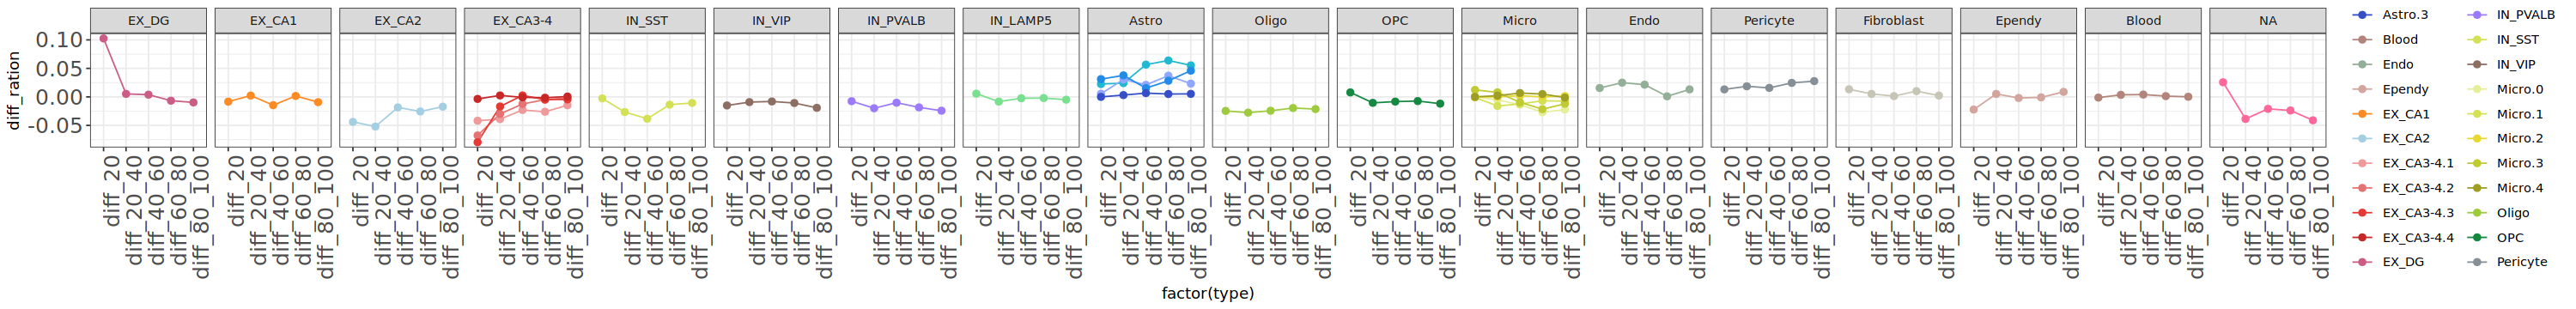

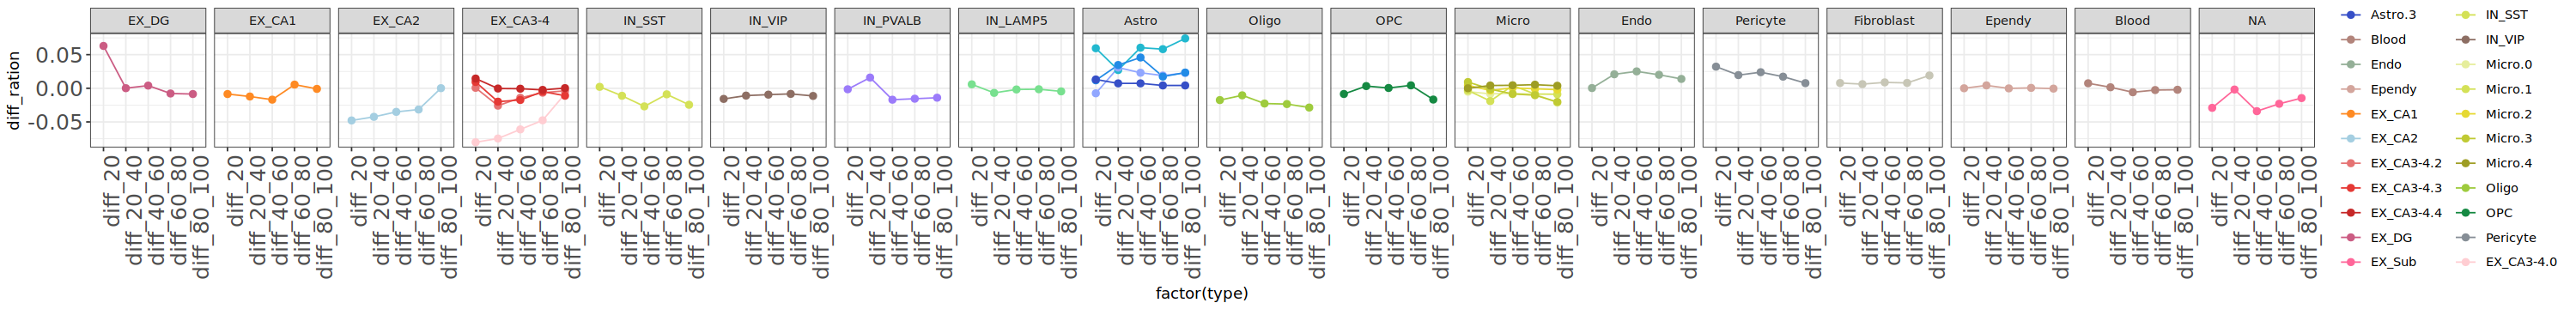

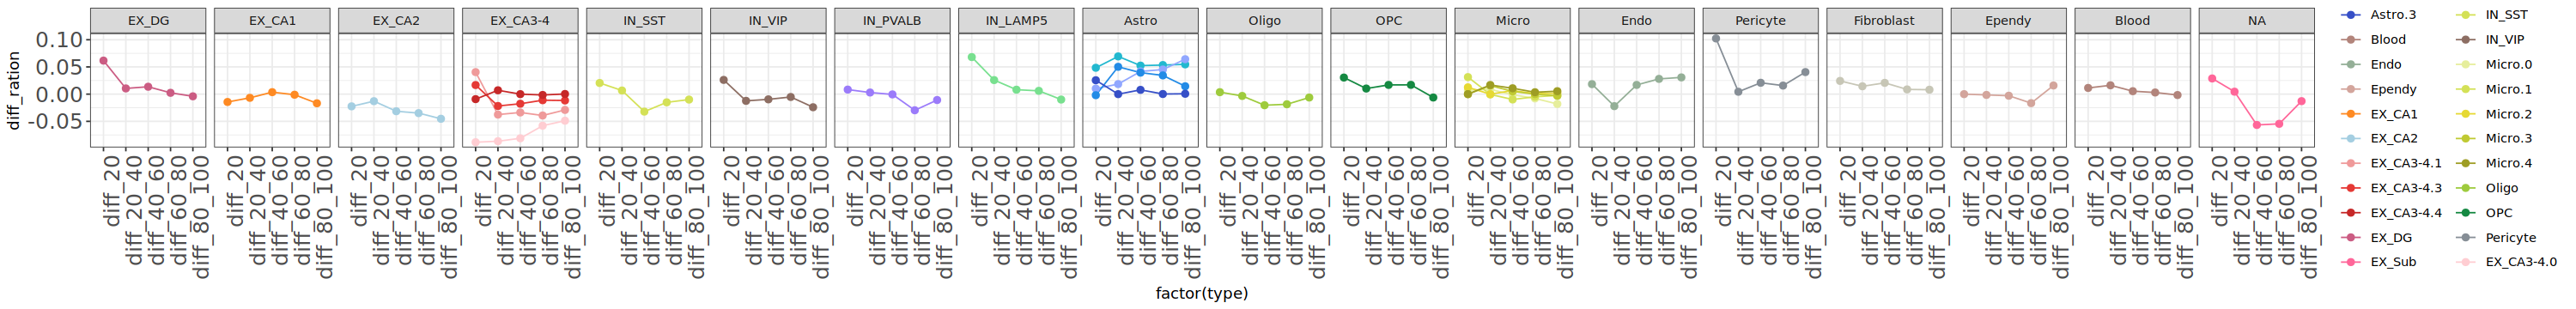

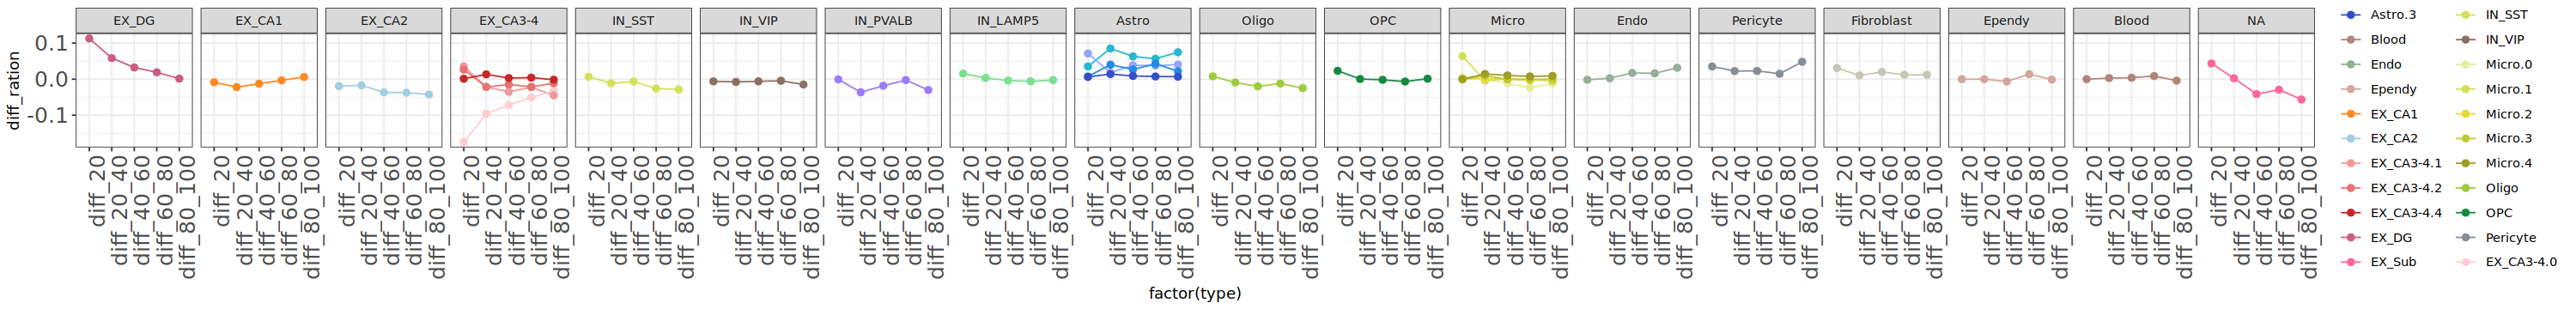

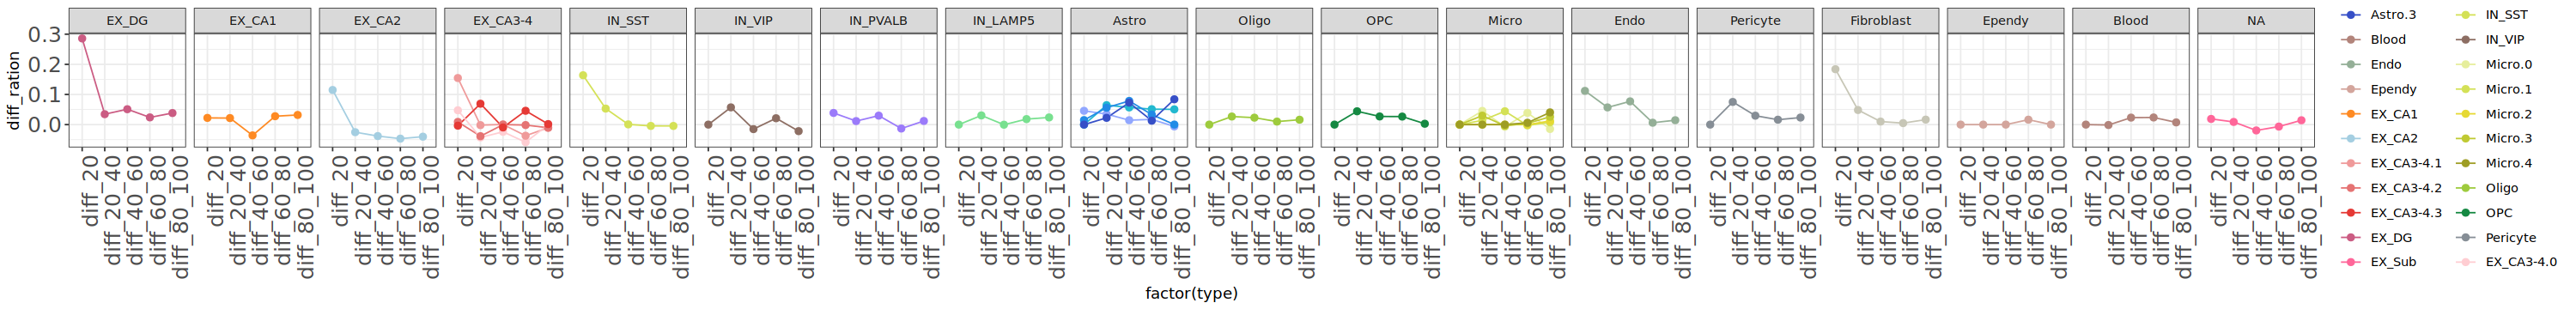

In [16]:
options(repr.plot.width=25, repr.plot.height=3)  
for (target in c('EX_CA3-4.0','EX_CA3-4.1','EX_CA3-4.2','EX_CA3-4.3','EX_CA3-4.4')){
    ratio.all1 = ratio.all %>% filter(target_cell_type %in% target)
    p1 = ggplot(ratio.all1, mapping = aes(x=factor(type), y= diff_ration, colour=cell_type,group=cell_type)) + 
        scale_color_manual("cell_type",values=cols)+
        geom_line(size=0.5) + geom_point(size=2)+theme_bw()+
        theme(axis.text.x = element_text(size = 15,angle=90,hjust=1),axis.text.y = element_text(size = 15))+
        facet_wrap(~factor(subclass,levels=subclass.levels),scales="fixed",nrow=1)#+ylim(-0.15, 0.1) 
    print(p1)
    assign(paste0(target,"_P"),p1)
    }

In [18]:
p = get('EX_CA3-4.0_P')+get('EX_CA3-4.1_P')+get('EX_CA3-4.2_P')+get('EX_CA3-4.3_P')+get('EX_CA3-4.4_P')
ggsave(plot=p,"EX_CA3-4.cell.diff.component.pdf",width=80,height=6,limitsize = FALSE)